**Простая линейная регрессия — от интуиции к коду**

Каждый раз, когда вы пытаетесь что-то предсказать — цену дома, зарплату, продажи следующего месяца — вы по сути занимаетесь регрессией, осознаёте вы это или нет. Давайте разберёмся с этим как следует.

**Что такое простая линейная регрессия?**

Простая регрессия — это статистический метод построения предиктивной модели для зависимой переменной "y". Проще говоря, это способ анализа и измерения взаимосвязи между одной независимой и одной зависимой переменной.

Давайте сделаем это конкретным. Представьте, что у нас есть датасет всего с двумя столбцами: **цена дома** и **площадь дома**. Наша цель — предсказать цену на основе площади. Математически это выражается так:

**f(x) = y = mx + b**

Но вот в чём настоящий вопрос — что такое **"m"** и **"b"**?

**Математика за прямой линией**

С точки зрения математики, линейная регрессия — это **аппроксимирующая прямая**, проведённая между двумя переменными. Уравнение этой прямой: **y = mx + b**, где:
- **m** — наклон: насколько изменяется y при увеличении x на единицу
- **b** — свободный член: точка пересечения прямой с осью y

Цель модели — найти такие значения m и b, которые дают наиболее точные предсказания. Для этого нам нужно измерить, насколько наша модель ошибается — и здесь на сцену выходит **функция потерь**.

**Функция потерь и OLS**

Функция потерь **J(m, b)** измеряет суммарную ошибку нашей модели. Математически она выглядит так:

**J(m, b) = Σ(y − ŷ)²**

Где **y** — реальное значение, а **ŷ** — предсказанное. Мы возводим разности в квадрат, чтобы сильнее штрафовать за большие ошибки и избежать взаимного погашения положительных и отрицательных ошибок.

Как мы минимизируем это? Цель — минимизировать сумму квадратов ошибок, это и есть **OLS-цель**. Под капотом sklearn решает эту задачу с помощью **SVD-разложения (сингулярное разложение)**, которое численно устойчивее, чем прямое вычисление нормального уравнения **(XᵀX)⁻¹Xᵀy**.


### Имплементация на Python

### Установка необходимых библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


### Создания датасеты для примера и создание модели

In [2]:
# Датасет: площадь дома (м²) и цена (тыс. $)
size = np.array([50, 70, 90, 110, 130, 150, 170]).reshape(-1, 1)
price = np.array([150, 200, 250, 290, 340, 400, 450])

# Обучение модели
model = LinearRegression()
model.fit(size, price)

m = model.coef_[0]
b = model.intercept_

print(f"Наклон        (m): {m:.2f}")
print(f"Свободный член(b): {b:.2f}")
print(f"Уравнение        : y = {m:.2f}x + {b:.2f}")


Наклон        (m): 2.48
Свободный член(b): 24.11
Уравнение        : y = 2.48x + 24.11


### Проверка метрик и визуализация

R² Score         : 1.00

Предсказанная цена дома 120 м²: $322.0k


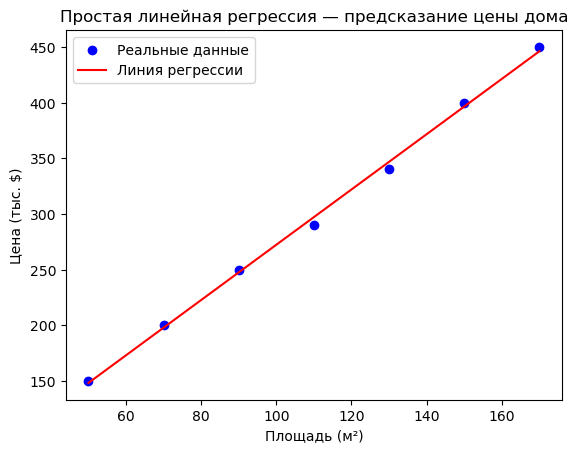

In [3]:
print(f"R² Score         : {model.score(size, price):.2f}")

predicted = model.predict([[120]])
print(f"\nПредсказанная цена дома 120 м²: ${predicted[0]:.1f}k")

# Визуализация
plt.scatter(size, price, color='blue', label='Реальные данные')
plt.plot(size, model.predict(size), color='red', label='Линия регрессии')
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (тыс. $)')
plt.title('Простая линейная регрессия — предсказание цены дома')
plt.legend()
plt.show()


**Важное ограничение**

Простая линейная регрессия предполагает **линейную зависимость** между переменными. Если реальная зависимость криволинейная или более сложная — модель будет работать плохо, как бы вы её ни настраивали. Всегда визуализируйте данные перед применением модели — простой scatter plot может сэкономить много времени.

**Заключение**

Простая линейная регрессия — один из самых элегантных инструментов в машинном обучении. Не потому что он мощный, а потому что он **интерпретируемый**. Вы можете взглянуть на уравнение и сразу понять, что выучила модель. В мире, где модели становятся всё сложнее и непрозрачнее, эта ясность по-прежнему имеет реальную ценность.

---
